# Deliverable 7 — Liver-Cropped Cascade + Augmentation + Tversky Loss

> Goal: lift **Tumor Dice** above the D6c-v1/v2 plateau (~0.57) by attacking the real bottleneck:
> **the tumor signal is too sparse** in full 128×128 slices.

### What changes vs D6c-v2
| Knob | D6c-v2 | **D7 cascade** |
|------|--------|----------------|
| Pipeline | single 3-class U-Net | **two-stage (liver → tumor-on-crop)** |
| Stage-2 input | full 512×512 → 128×128 | **liver-bbox crop → 128×128** (zoomed in) |
| Stage-2 task | 3-class | **binary (tumor vs not-tumor)** |
| Loss | Dice + CE | **Tversky(α=0.3, β=0.7) + CE** |
| Augmentation | OFF | **medium** (flip, rot ±7°, brightness, contrast) |
| Stage-1 model | — | **D6c-v2 frozen, reused** |

### Honest caveats
1. **Three changes at once** (cascade + augmentation + Tversky). If we improve, we can't attribute the gain cleanly. Run ablations afterwards if needed.
2. **Stage-2 trains and evaluates with GT liver bbox** = oracle setting. The "real" deployment number requires end-to-end eval (Section 9).
3. **Headline number** = end-to-end Stage-1 → Stage-2 tumor Dice. The oracle number is also reported as an upper bound.

## 1. Imports

In [1]:
import os, json, time, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from lits_core import (get_device, load_lits_paths, make_split,
                       LiTS25DDataset, UNet2D, compute_dice_per_class)
from lits_cascade import (combined_tversky_loss, tversky_loss,
                          LiTSLiverCroppedDataset, liver_bbox,
                          stage1_predict_liver_mask)

device = get_device()
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.11.0+cu128


## 2. Configuration

In [2]:
DATA_DIR    = '/home/adnan/aeman_dl/archive-2'
OUT_DIR     = './out_d7_cascade'
TAG         = 'D7-cascade'

# Shared
IMG_SIZE    = 128
STACK_SIZE  = 5
SEED        = 42

# Stage 1 (frozen, loaded from D6c-v2)
STAGE1_CKPT = './out_d6c_v2/best_unet_d6c_v2.pth'
STAGE1_DROPOUT_P = 0.3   # must match how D6c-v2 was built (bottleneck wrap)

# Stage 2 (the new training)
S2_BATCH       = 16
S2_NUM_EPOCHS  = 30
S2_LR          = 1e-4
S2_WD          = 1e-5
S2_ETA_MIN     = 1e-7
S2_PAD_FRAC    = 0.05         # padding around liver bbox
S2_TVERSKY_A   = 0.3          # FP weight (smaller = more tolerant of FP)
S2_TVERSKY_B   = 0.7          # FN weight (larger = penalize missed tumor more)
S2_AUG         = True
S2_AUG_STR     = 'medium'

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Stage-1 checkpoint: {STAGE1_CKPT}')
print(f'Stage-2: {S2_NUM_EPOCHS} epochs | bs={S2_BATCH} | LR cosine {S2_LR}->{S2_ETA_MIN}')
print(f'Stage-2 loss: Tversky(a={S2_TVERSKY_A}, b={S2_TVERSKY_B}) + CE')
print(f'Stage-2 aug: {S2_AUG} ({S2_AUG_STR})')

Stage-1 checkpoint: ./out_d6c_v2/best_unet_d6c_v2.pth
Stage-2: 30 epochs | bs=16 | LR cosine 0.0001->1e-07
Stage-2 loss: Tversky(a=0.3, b=0.7) + CE
Stage-2 aug: True (medium)


## 3. Data Loading & Split (identical seed=42)

In [3]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)
train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED)

Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 4. Build Stage-1 (D6c-v2) and Freeze

We rebuild the architecture with the bottleneck dropout wrap (so state_dict keys match), load the v2 checkpoint, and put it in eval mode. **No gradients.** Stage 1 is used only to compute the liver bounding box at inference time.

In [4]:
stage1 = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
                use_attention=False).to(device)
# Match D6c-v2's bottleneck wrap so state_dict keys align
original_bn = stage1.bottleneck
stage1.bottleneck = nn.Sequential(original_bn, nn.Dropout2d(p=STAGE1_DROPOUT_P)).to(device)

if not os.path.exists(STAGE1_CKPT):
    raise FileNotFoundError(
        f'Stage-1 checkpoint not found at {STAGE1_CKPT}. '
        'Finish D6c-v2 training first (it saves at end of run).')

state = torch.load(STAGE1_CKPT, map_location=device)
stage1.load_state_dict(state)
stage1.eval()
for p in stage1.parameters():
    p.requires_grad = False
print(f'Stage-1 loaded and frozen. Params: {sum(p.numel() for p in stage1.parameters()):,}')

Stage-1 loaded and frozen. Params: 31,038,915


## 5. Stage-2 Datasets — Liver-Cropped, Augmented

Each sample is the CT slice cropped to its **GT** liver bounding box, padded by 5%, resized to 128×128. Target is binary {0, 1}: *tumor* vs *everything else*.

Why GT crop at training time? Clean signal. Stage 2 sees the tumor inside a tight liver patch with no Stage-1 errors. The end-to-end evaluation in §9 uses Stage-1's *predicted* bbox, which is the realistic number.

In [5]:
print('Building Stage-2 train (cropped, aug=ON)...')
s2_train = LiTSLiverCroppedDataset(
    train_v, train_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=S2_AUG, aug_strength=S2_AUG_STR)

print('\nBuilding Stage-2 val (cropped, aug=OFF — keep eval honest)...')
s2_val = LiTSLiverCroppedDataset(
    val_v, val_s, img_size=IMG_SIZE, stack_size=STACK_SIZE,
    pad_frac=S2_PAD_FRAC, augment=False)

s2_train_loader = DataLoader(s2_train, batch_size=S2_BATCH, shuffle=True,
                             num_workers=0, pin_memory=False)
s2_val_loader   = DataLoader(s2_val,   batch_size=S2_BATCH, shuffle=False,
                             num_workers=0, pin_memory=False)
print(f'\nTrain batches: {len(s2_train_loader)} | Val batches: {len(s2_val_loader)}')

Building Stage-2 train (cropped, aug=ON)...
CroppedDataset: 4614 slices (1594 with tumor, 3020 liver-only) | skipped 8101 bg-only | stack=5 | augment=True (medium)

Building Stage-2 val (cropped, aug=OFF — keep eval honest)...
CroppedDataset: 1116 slices (327 with tumor, 789 liver-only) | skipped 1474 bg-only | stack=5 | augment=False (medium)

Train batches: 289 | Val batches: 70


## 6. Build Stage-2 Model — Binary Tumor U-Net

Same UNet2D backbone, but `num_classes=2` (background, tumor). No bottleneck dropout this time — augmentation is doing the regularization, and the v2 result told us dropout didn't help.

In [6]:
s2_model = UNet2D(in_channels=STACK_SIZE, num_classes=2, base_features=64,
                  use_attention=False).to(device)
n_params = sum(p.numel() for p in s2_model.parameters() if p.requires_grad)
print(f'Stage-2 model params: {n_params:,}')

# Sanity check
with torch.no_grad():
    test_in = torch.randn(2, STACK_SIZE, IMG_SIZE, IMG_SIZE).to(device)
    test_out = s2_model(test_in)
    print(f'Forward: {tuple(test_in.shape)} -> {tuple(test_out.shape)}  (expect [2, 2, 128, 128])')

Stage-2 model params: 31,038,850
Forward: (2, 5, 128, 128) -> (2, 2, 128, 128)  (expect [2, 2, 128, 128])


## 7. Train Stage-2 — Cosine LR + Tversky+CE

`combined_tversky_loss(α=0.3, β=0.7)` + CrossEntropy. Tversky's β > α makes the loss penalize missed-tumor pixels more than false alarms — exactly what we want for sparse tumors.

In [7]:
torch.manual_seed(SEED)

optimizer = torch.optim.Adam(s2_model.parameters(), lr=S2_LR, weight_decay=S2_WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=S2_NUM_EPOCHS, eta_min=S2_ETA_MIN)

history = {k: [] for k in
           ['train_loss', 'val_loss', 'val_tumor_dice', 'epoch_mins', 'lr']}
best_tumor = 0.0
best_state = None

print('=' * 78)
print(f'TRAINING: {TAG} STAGE-2  (cropped + aug + Tversky)')
print(f'  Epochs={S2_NUM_EPOCHS} | LR={S2_LR}->{S2_ETA_MIN} (cosine) | WD={S2_WD}')
print(f'  Tversky alpha={S2_TVERSKY_A} beta={S2_TVERSKY_B}')
print('=' * 78)

def tumor_dice_binary(preds, targets, smooth=1e-6):
    pred_cls = preds.argmax(dim=1)
    p = (pred_cls == 1).float()
    t = (targets == 1).float()
    inter = (p * t).sum()
    denom = p.sum() + t.sum()
    return ((2 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0

for epoch in range(1, S2_NUM_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    s2_model.train()
    train_losses = []
    for bi, (ct, seg) in enumerate(s2_train_loader):
        ct, seg = ct.to(device), seg.to(device)
        optimizer.zero_grad()
        preds = s2_model(ct)
        loss = combined_tversky_loss(preds, seg, alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (bi + 1) % 100 == 0:
            print(f'  [{TAG}] Ep {epoch:02d} batch {bi+1}/{len(s2_train_loader)} '
                  f'loss={loss.item():.4f}')

    s2_model.eval()
    val_losses, tumors = [], []
    with torch.no_grad():
        for ct, seg in s2_val_loader:
            ct, seg = ct.to(device), seg.to(device)
            preds = s2_model(ct)
            val_losses.append(combined_tversky_loss(
                preds, seg, alpha=S2_TVERSKY_A, beta=S2_TVERSKY_B).item())
            tumors.append(tumor_dice_binary(preds, seg))

    m_train = float(np.mean(train_losses))
    m_val   = float(np.mean(val_losses))
    m_tumor = float(np.mean(tumors))
    em = (time.time() - t0) / 60

    history['train_loss'].append(m_train)
    history['val_loss'].append(m_val)
    history['val_tumor_dice'].append(m_tumor)
    history['epoch_mins'].append(em)
    history['lr'].append(current_lr)

    scheduler.step()

    flag = ''
    if m_tumor > best_tumor:
        best_tumor = m_tumor
        best_state = {k: v.cpu().clone() for k, v in s2_model.state_dict().items()}
        flag = ' *** BEST'

    print(f'[{TAG}] Ep {epoch:02d}/{S2_NUM_EPOCHS} | {em:4.1f}min | '
          f'LR={current_lr:.2e} | Train: {m_train:.4f} | Val: {m_val:.4f} | '
          f'Tumor: {m_tumor:.4f}{flag}')

save_path = os.path.join(OUT_DIR, 'best_stage2_tumor.pth')
if best_state is not None:
    torch.save(best_state, save_path)
    print(f'\nSaved Stage-2 best to {save_path}')

print(f'\n{TAG} Stage-2 best Tumor Dice (oracle bbox): {best_tumor:.4f}')
print('  (This is the upper bound — end-to-end eval in Section 9 uses Stage-1 bbox.)')

TRAINING: D7-cascade STAGE-2  (cropped + aug + Tversky)
  Epochs=30 | LR=0.0001->1e-07 (cosine) | WD=1e-05
  Tversky alpha=0.3 beta=0.7
  [D7-cascade] Ep 01 batch 100/289 loss=1.1666
  [D7-cascade] Ep 01 batch 200/289 loss=1.1526
[D7-cascade] Ep 01/30 |  2.3min | LR=1.00e-04 | Train: 1.0366 | Val: 1.1105 | Tumor: 0.1660 *** BEST
  [D7-cascade] Ep 02 batch 100/289 loss=0.7909
  [D7-cascade] Ep 02 batch 200/289 loss=0.7089
[D7-cascade] Ep 02/30 |  2.0min | LR=9.97e-05 | Train: 0.7275 | Val: 1.0436 | Tumor: 0.5041 *** BEST
  [D7-cascade] Ep 03 batch 100/289 loss=0.4478
  [D7-cascade] Ep 03 batch 200/289 loss=0.2982
[D7-cascade] Ep 03/30 |  2.0min | LR=9.89e-05 | Train: 0.5293 | Val: 1.0509 | Tumor: 0.4346
  [D7-cascade] Ep 04 batch 100/289 loss=0.2852
  [D7-cascade] Ep 04 batch 200/289 loss=0.3204
[D7-cascade] Ep 04/30 |  2.0min | LR=9.76e-05 | Train: 0.4177 | Val: 1.0001 | Tumor: 0.4448
  [D7-cascade] Ep 05 batch 100/289 loss=0.4436
  [D7-cascade] Ep 05 batch 200/289 loss=0.1526
[D7-casc

## 8. Training Curves

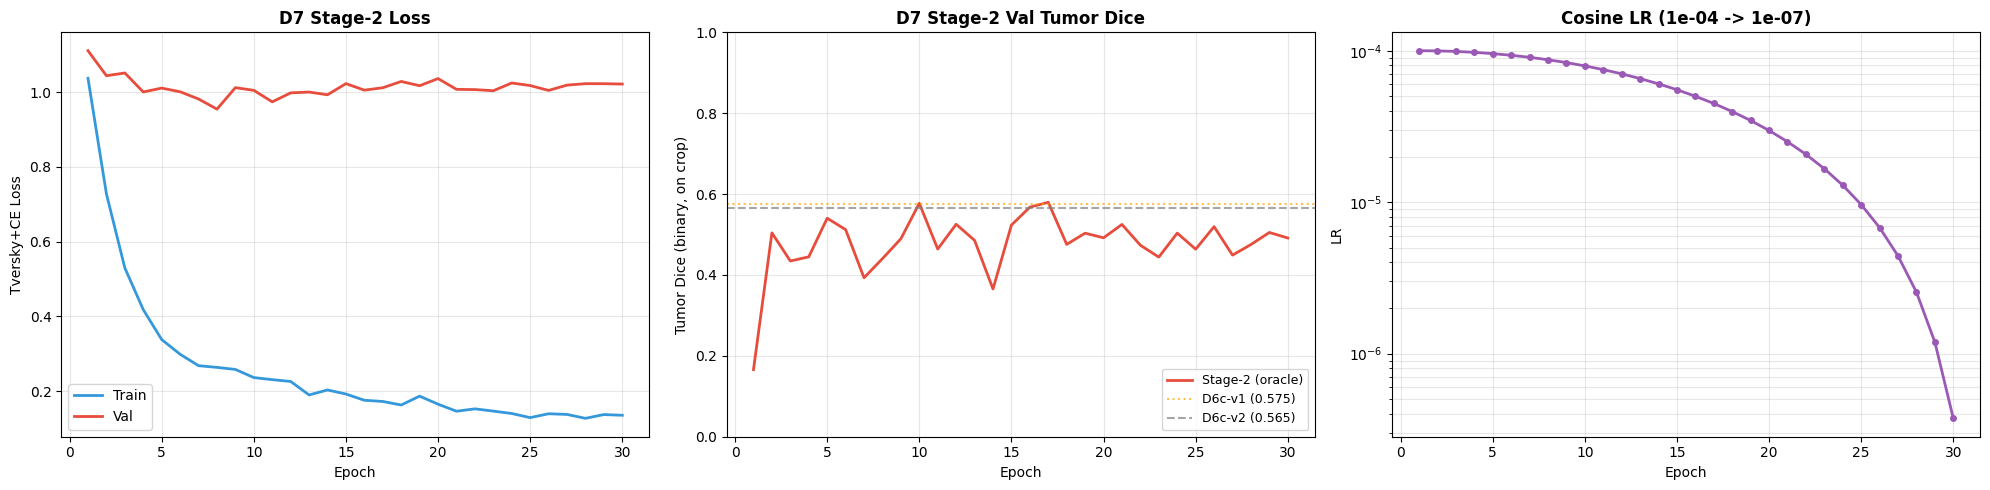

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ep = range(1, S2_NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Tversky+CE Loss')
axes[0].set_title('D7 Stage-2 Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

D6CV1_TUMOR = 0.5749
D6CV2_TUMOR = 0.5649
axes[1].plot(ep, history['val_tumor_dice'], color='#e74c3c', linewidth=2, label='Stage-2 (oracle)')
axes[1].axhline(D6CV1_TUMOR, ls=':',  color='orange', alpha=0.7, label=f'D6c-v1 ({D6CV1_TUMOR:.3f})')
axes[1].axhline(D6CV2_TUMOR, ls='--', color='gray',   alpha=0.7, label=f'D6c-v2 ({D6CV2_TUMOR:.3f})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Tumor Dice (binary, on crop)')
axes[1].set_ylim(0, 1)
axes[1].set_title('D7 Stage-2 Val Tumor Dice', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['lr'], color='#9b59b6', linewidth=2, marker='o', markersize=4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].set_title(f'Cosine LR ({S2_LR:.0e} -> {S2_ETA_MIN:.0e})', fontweight='bold')
axes[2].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_d7.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. End-to-End Evaluation — Stage-1 Bbox → Stage-2 Tumor

The oracle number (Section 7) used GT liver bbox. The realistic number uses Stage-1's *predicted* liver region: any error in Stage 1's bbox propagates to Stage 2.

For each val volume slice:
1. Run Stage-1 on the full-size 128×128 input → predicted (liver+tumor) mask
2. Compute bbox of that mask
3. If empty (no liver predicted), Stage-2 prediction = all background
4. Else: crop the original full-resolution CT to that bbox, resize, run Stage-2
5. Paste Stage-2 tumor prediction back into the full 128×128 frame
6. Compute tumor Dice against the GT seg at full 128×128

This is the number you'd report as the deployable result.

In [9]:
s2_model.load_state_dict(best_state)
s2_model.eval()

# We need access to raw volumes to do the full-res cascade properly. The
# val_v / val_s lists give us paths.
import nibabel as nib
from scipy import ndimage

HU_MIN, HU_MAX = -100, 400

def normalize_ct(slice_2d):
    x = np.clip(slice_2d, HU_MIN, HU_MAX)
    return ((x - HU_MIN) / (HU_MAX - HU_MIN)).astype(np.float32)

def resize2d(arr, h, w, order):
    return ndimage.zoom(arr, (h / arr.shape[0], w / arr.shape[1]), order=order)

@torch.no_grad()
def cascade_predict_slice(vol, seg_full, slice_idx, n_slices):
    """Returns (gt_full128, pred_full128) at 128x128."""
    half = STACK_SIZE // 2
    stack_idxs = [max(0, min(n_slices - 1, slice_idx + off))
                  for off in range(-half, half + 1)]

    # ---- Stage 1: full slice resized to 128x128 ----
    ct_full_chs = [resize2d(normalize_ct(vol[:, :, i]), IMG_SIZE, IMG_SIZE, order=1)
                   for i in stack_idxs]
    ct_full = np.stack(ct_full_chs, axis=0)
    ct_full_t = torch.from_numpy(ct_full).unsqueeze(0).to(device)
    s1_logits = stage1(ct_full_t)
    s1_pred = s1_logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    liver_mask_128 = (s1_pred > 0).astype(np.uint8)

    # GT at 128x128
    gt_128 = resize2d(seg_full[:, :, slice_idx].astype(np.float32),
                      IMG_SIZE, IMG_SIZE, order=0).astype(np.int64)

    # ---- Stage 2: crop to predicted liver bbox, run, paste back ----
    pred_tumor_128 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    bbox = liver_bbox(liver_mask_128, pad_frac=S2_PAD_FRAC)
    if bbox is not None:
        r0, r1, c0, c1 = bbox
        # Crop the (already normalized & resized) CT stack and run Stage 2
        ct_crop = np.stack([
            resize2d(ct_full[c, r0:r1, c0:c1], IMG_SIZE, IMG_SIZE, order=1)
            for c in range(STACK_SIZE)
        ], axis=0).astype(np.float32)
        ct_crop_t = torch.from_numpy(ct_crop).unsqueeze(0).to(device)
        s2_logits = s2_model(ct_crop_t)
        s2_pred_crop = s2_logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        # Paste back: resize crop-space prediction back into bbox of 128x128 frame
        bh, bw = (r1 - r0), (c1 - c0)
        s2_pred_resized = resize2d(s2_pred_crop.astype(np.float32),
                                   bh, bw, order=0).astype(np.uint8)
        pred_tumor_128[r0:r1, c0:c1] = s2_pred_resized

    return gt_128, pred_tumor_128

# Iterate over all val slices that contain liver
print('Running end-to-end cascade on val set...')
e2e_dices = []
slices_with_tumor = 0
e2e_samples = []

for vp, sp in zip(val_v, val_s):
    vol = nib.load(vp).get_fdata().astype(np.float32)
    seg = nib.load(sp).get_fdata().astype(np.uint8)
    n_slices = vol.shape[2]
    for s in range(n_slices):
        if not np.any(seg[:, :, s] > 0):
            continue
        gt_128, pred_tumor = cascade_predict_slice(vol, seg, s, n_slices)
        gt_t = (gt_128 == 2).astype(np.uint8)
        if gt_t.sum() < 30:  # match qualitative threshold
            continue
        slices_with_tumor += 1
        inter = (pred_tumor * gt_t).sum()
        denom = pred_tumor.sum() + gt_t.sum()
        d = (2 * inter / denom) if denom > 0 else 0.0
        e2e_dices.append(float(d))
        if len(e2e_samples) < 200:  # cap memory
            mid = STACK_SIZE // 2
            ct_mid = resize2d(normalize_ct(vol[:, :, s]), IMG_SIZE, IMG_SIZE, order=1)
            e2e_samples.append({
                'ct': ct_mid, 'gt': gt_128, 'pred_tumor': pred_tumor,
                'dice': float(d), 'tumor_px': int(gt_t.sum()),
            })

e2e_mean = float(np.mean(e2e_dices)) if e2e_dices else 0.0
e2e_med  = float(np.median(e2e_dices)) if e2e_dices else 0.0
print(f'\nEnd-to-end: {slices_with_tumor} val slices with tumor (>30px)')
print(f'  Mean tumor Dice  : {e2e_mean:.4f}')
print(f'  Median tumor Dice: {e2e_med:.4f}')
print(f'  % slices Dice>0.3: {100*np.mean([d>0.3 for d in e2e_dices]):.1f}%')

Running end-to-end cascade on val set...

End-to-end: 184 val slices with tumor (>30px)
  Mean tumor Dice  : 0.2097
  Median tumor Dice: 0.0000
  % slices Dice>0.3: 25.5%


## 10. Final Comparison Table

In [10]:
D3_TUMOR    = 0.5011
D6_TUMOR    = 0.5314
D6CV1_TUMOR = 0.5749
D6CV2_TUMOR = 0.5649

result = {
    'tag': TAG,
    'stage2_oracle_tumor_dice': best_tumor,
    'end_to_end_tumor_dice_mean': e2e_mean,
    'end_to_end_tumor_dice_median': e2e_med,
    'config': {
        'stack_size': STACK_SIZE,
        'tversky_alpha': S2_TVERSKY_A,
        'tversky_beta': S2_TVERSKY_B,
        'augmentation': S2_AUG_STR,
        'epochs': S2_NUM_EPOCHS,
        'lr_peak': S2_LR,
    },
    'history': history,
}
with open(os.path.join(OUT_DIR, 'results.json'), 'w') as f:
    json.dump(result, f, indent=2)

print('=' * 88)
print(f'{TAG} RESULTS')
print('=' * 88)
print(f'{"Method":40s}{"Tumor Dice":>14s}{"vs D6c-v1":>14s}')
print('-' * 88)
print(f'{"D3 baseline":40s}{D3_TUMOR:>14.4f}{D3_TUMOR-D6CV1_TUMOR:>+14.4f}')
print(f'{"D6 (stack=3)":40s}{D6_TUMOR:>14.4f}{D6_TUMOR-D6CV1_TUMOR:>+14.4f}')
print(f'{"D6c-v1 (stack=5)":40s}{D6CV1_TUMOR:>14.4f}{0.0:>+14.4f}')
print(f'{"D6c-v2 (cosine+dropout)":40s}{D6CV2_TUMOR:>14.4f}{D6CV2_TUMOR-D6CV1_TUMOR:>+14.4f}')
print(f'{"D7 cascade — oracle bbox (UB)":40s}{best_tumor:>14.4f}{best_tumor-D6CV1_TUMOR:>+14.4f}')
print(f'{"D7 cascade — end-to-end (HEADLINE)":40s}{e2e_mean:>14.4f}{e2e_mean-D6CV1_TUMOR:>+14.4f}')
print('=' * 88)

D7-cascade RESULTS
Method                                      Tumor Dice     vs D6c-v1
----------------------------------------------------------------------------------------
D3 baseline                                     0.5011       -0.0738
D6 (stack=3)                                    0.5314       -0.0435
D6c-v1 (stack=5)                                0.5749       +0.0000
D6c-v2 (cosine+dropout)                         0.5649       -0.0100
D7 cascade — oracle bbox (UB)                   0.5797       +0.0048
D7 cascade — end-to-end (HEADLINE)              0.2097       -0.3652


## 11. Qualitative — End-to-End Cascade

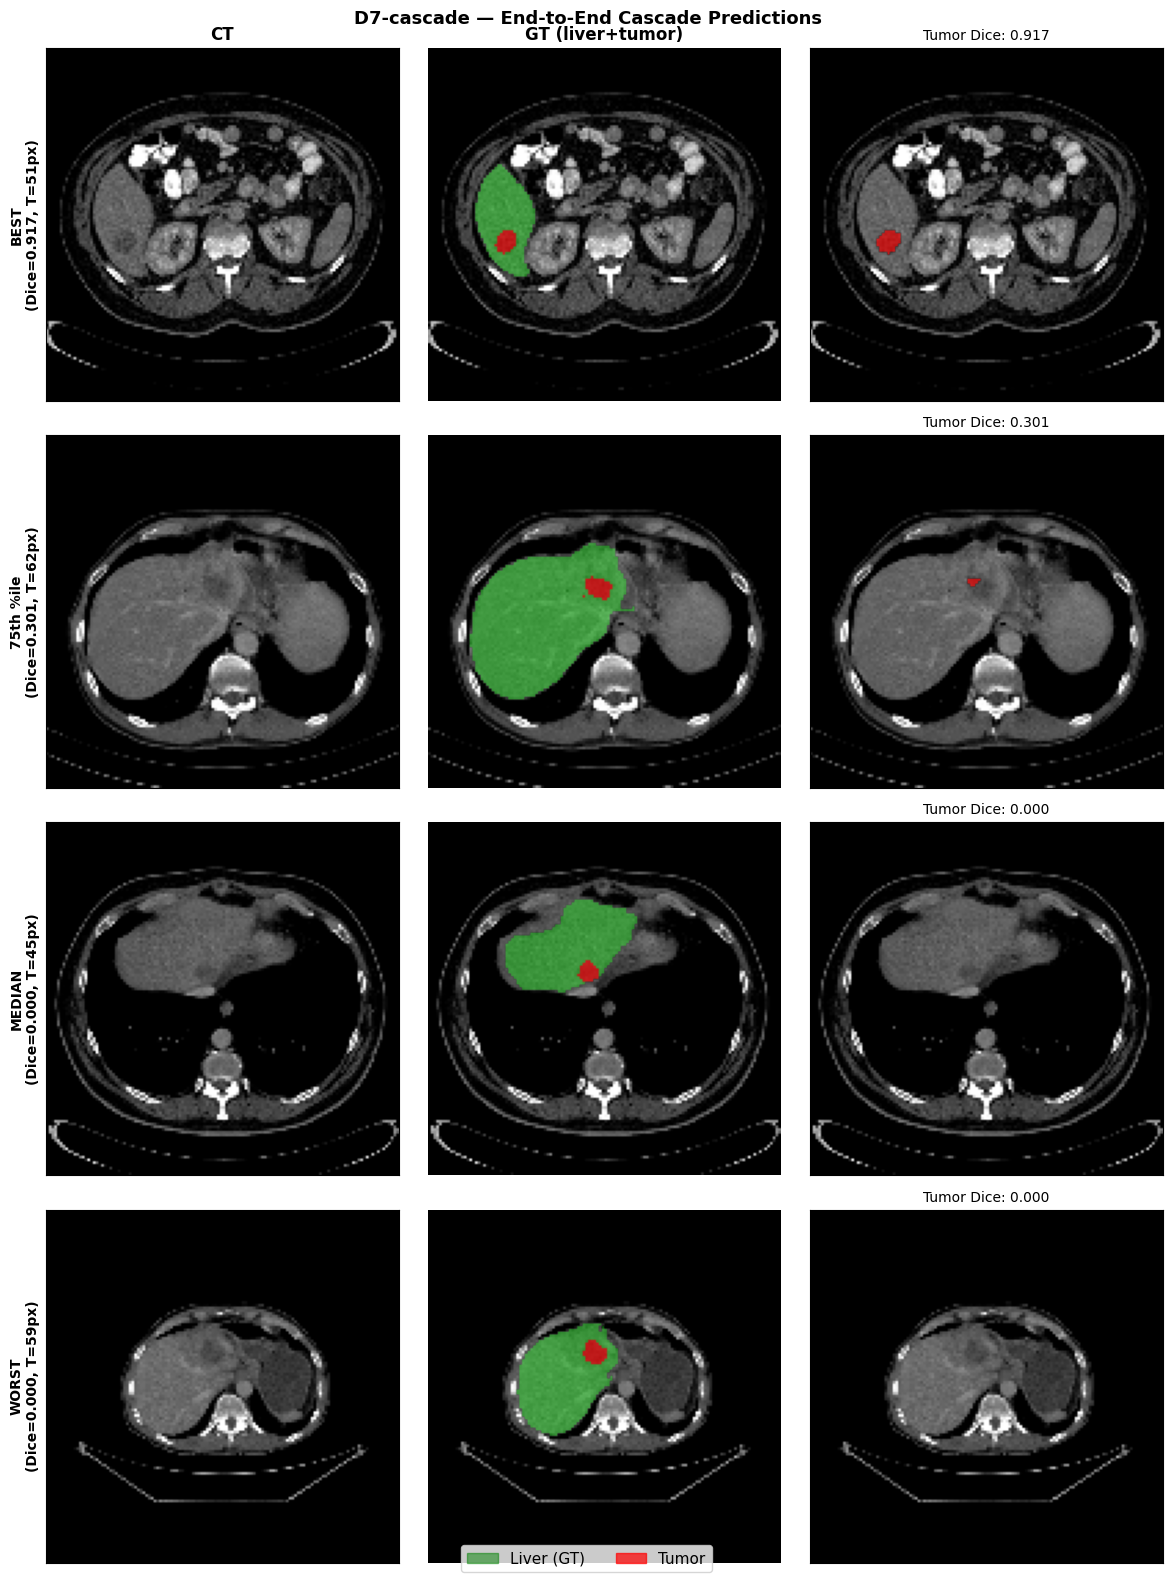

In [11]:
if e2e_samples:
    e2e_samples.sort(key=lambda s: s['dice'], reverse=True)
    n_total = len(e2e_samples)
    picks = [(0, 'BEST'),
             (n_total // 4, '75th %ile'),
             (n_total // 2, 'MEDIAN'),
             (n_total - 1, 'WORST')] if n_total >= 4 else [(i, f'#{i}') for i in range(n_total)]

    def overlay(seg_3cls, _ct):
        o = np.zeros((*_ct.shape, 4))
        o[seg_3cls == 1] = [0, 1, 0, 0.35]
        o[seg_3cls == 2] = [1, 0, 0, 0.65]
        return o

    def overlay_tumor(tumor_mask, _ct):
        o = np.zeros((*_ct.shape, 4))
        o[tumor_mask == 1] = [1, 0, 0, 0.65]
        return o

    n = len(picks)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1: axes = [axes]
    for col, t in enumerate(['CT', 'GT (liver+tumor)', 'Cascade tumor pred']):
        axes[0][col].set_title(t, fontsize=12, fontweight='bold')
    for row, (i, lbl) in enumerate(picks):
        s = e2e_samples[i]
        ct, gt, pr, d = s['ct'], s['gt'], s['pred_tumor'], s['dice']
        axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][0].set_ylabel(f'{lbl}\n(Dice={d:.3f}, T={s["tumor_px"]}px)',
                                fontsize=10, fontweight='bold')
        axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
        axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][1].imshow(overlay(gt, ct).transpose(1,0,2), origin='lower')
        axes[row][1].axis('off')
        axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
        axes[row][2].imshow(overlay_tumor(pr, ct).transpose(1,0,2), origin='lower')
        axes[row][2].set_title(f'Tumor Dice: {d:.3f}', fontsize=10)
        axes[row][2].set_xticks([]); axes[row][2].set_yticks([])
    g = mpatches.Patch(color='green', alpha=0.5, label='Liver (GT)')
    r = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
    fig.legend(handles=[g, r], loc='lower center', ncol=2, fontsize=11)
    plt.suptitle(f'{TAG} — End-to-End Cascade Predictions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'qualitative_d7.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No qualitative samples collected.')